In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ai-impact-jobs-layoff-risk-dataset.csv')
# First 5 rows
print(df.head())

# Dataset information
print("\nDataset Information:")
print(df.info())

# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

   Age Education_Level  Years_of_Experience       Industry  \
0   59        Master's                    6        Finance   
1   44        Master's                   14  Manufacturing   
2   36      Bachelor's                    7         Retail   
3   27      Bachelor's                    6        Finance   
4   49     High School                   12        Finance   

                Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
0             Accountant       Medium     Entry                       84   
1  Production Supervisor        Small     Entry                       30   
2          Store Manager       Medium    Senior                       12   
3                Auditor        Large     Entry                       90   
4                Auditor        Small     Entry                       49   

   Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
0                      21                       94            Medium   
1                      84 

In [3]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [4]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numerical Columns:
Index(['Age', 'Years_of_Experience', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
       'Tasks_Automated_Percentage', 'AI_Training_Hours'],
      dtype='object')

Categorical Columns:
Index(['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level',
       'AI_Adoption_Level', 'Layoff_Risk'],
      dtype='object')


In [5]:
z_scores = df[numerical_cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

threshold = 3

outliers = df[(np.abs(z_scores) > threshold).any(axis=1)]

print("Total outliers:", outliers.shape[0])
print(outliers.head())

Total outliers: 1097
     Age Education_Level  Years_of_Experience       Industry  \
29    36      Bachelor's                    9        Finance   
31    30     High School                    6  Manufacturing   
32    56        Master's                   11      Education   
56    23             PhD                    0      Logistics   
118   58        Master's                    8         Retail   

                 Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
29             Accountant        Small       Mid                       93   
31       Quality Engineer        Large     Entry                       77   
32                Teacher        Large     Entry                       91   
56   Supply Chain Analyst        Small     Entry                       84   
118     Inventory Analyst        Large    Senior                       83   

     Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
29                        0                       52     

In [7]:
df = df[(z_scores < 3).all(axis=1)]

print("Original shape:", df.shape)
print("After removing outliers:", df.shape)
print("Outliers removed:", df.shape[0] - df.shape[0])

Original shape: (18903, 16)
After removing outliers: (18903, 16)
Outliers removed: 0


C:\Users\sahit\AppData\Local\Temp\ipykernel_24888\863914203.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[(z_scores < 3).all(axis=1)]


In [8]:
for colname in categorical_cols:
    print(f'{colname} : {len(df[colname].unique())}')

Education_Level : 4
Industry : 8
Job_Role : 24
Company_Size : 3
Job_Level : 3
AI_Adoption_Level : 3
Layoff_Risk : 3


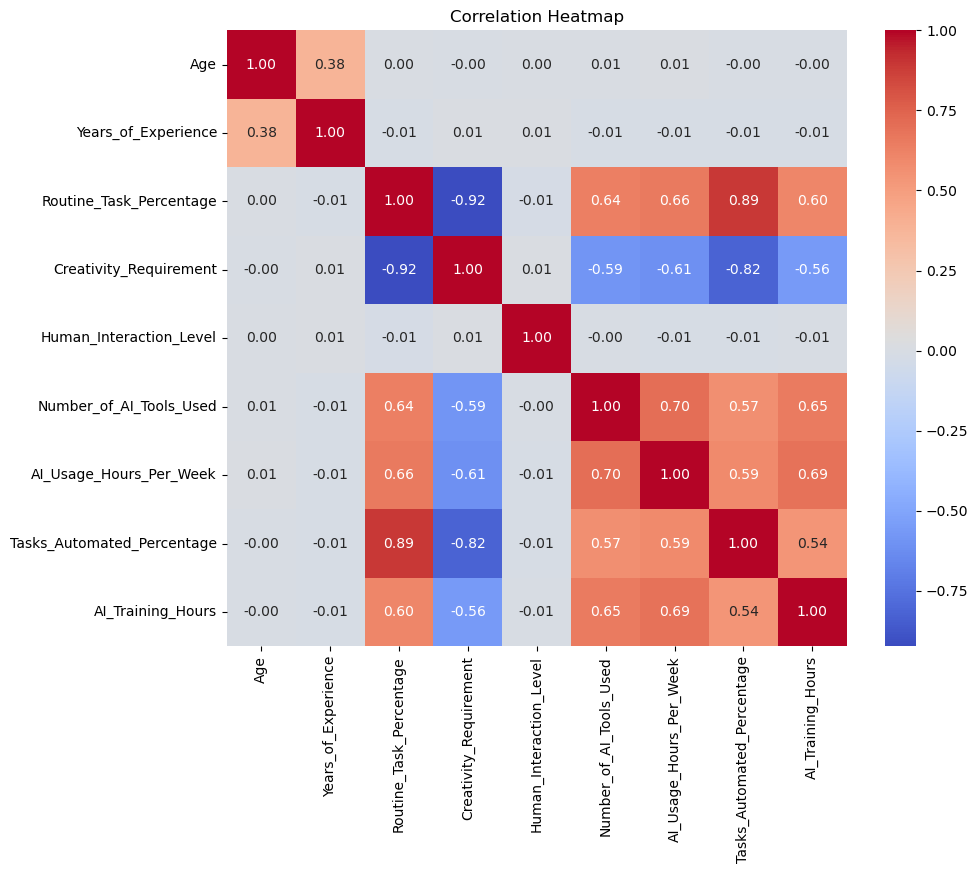

In [9]:
# ===========================
# 6. Correlation Heatmap
# ===========================

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()


In [10]:
# ===========================
# 11. Label Encoding
# ===========================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = [
    'Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level',
       'AI_Adoption_Level', 'Layoff_Risk'
]

for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
df.isnull().sum()

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

In [12]:
df.to_csv('ai-impact-jobs-layoff-risk-cleaned.csv')